# Aufgabe 2

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.morphology import disk, erosion, dilation, label

# We do not use binary_erosion and binary_dilation because they will be deprecated in future versions of skimage.
# Instead, we use erosion and dilation directly on binary images because the speedup is negligible for our use case.

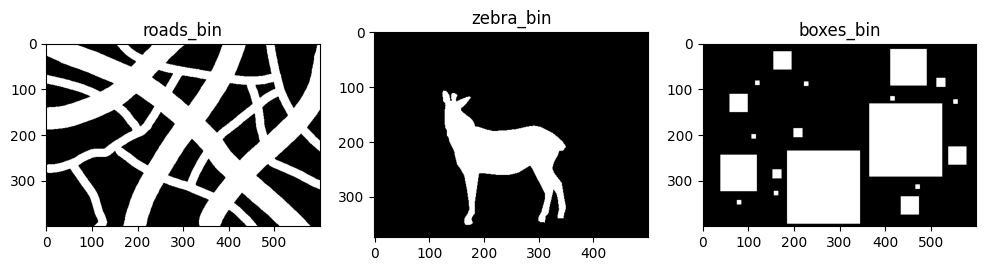

In [2]:
roads_bin = imread('roads_bin.png')
zebra_bin = imread('zebra_bin.png')
boxes_bin = imread('boxes_bin.png')

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(roads_bin, cmap='gray')
plt.title('roads_bin')

plt.subplot(1, 3, 2)
plt.imshow(zebra_bin, cmap='gray')
plt.title('zebra_bin')

plt.subplot(1, 3, 3)
plt.imshow(boxes_bin, cmap='gray')
plt.title('boxes_bin')

plt.show()

## 2.1

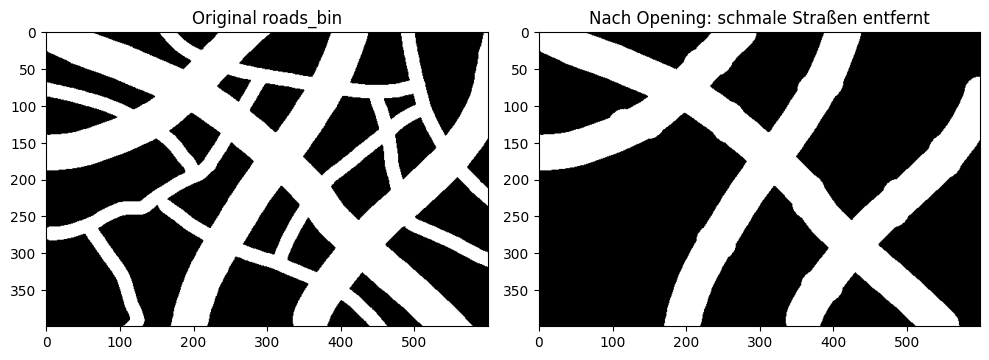

In [3]:
se = disk(22)                                # Structuring element: disk with radius 22
roads_eroded = erosion(roads_bin, se)        # Erosion removes narrow roads and shrinks wide roads
roads_morphed = dilation(roads_eroded, se)   # Dilation restores the remaining wide roads

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(roads_bin, cmap='gray')
plt.title('Original roads_bin')

plt.subplot(1, 2, 2)
plt.imshow(roads_morphed, cmap='gray')
plt.title('Nach Opening: schmale Straßen entfernt')

plt.tight_layout()
plt.show()


## 2.2

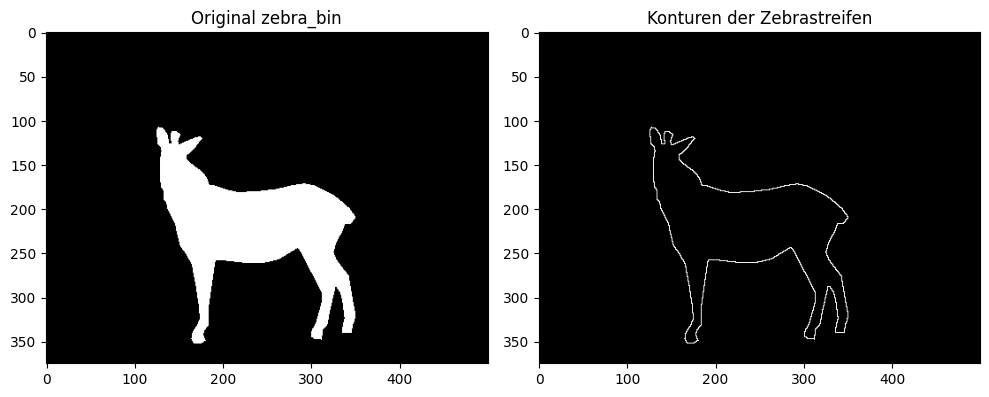

Contour pixel coutnt: 1469


In [4]:
se = np.ones((3, 3), dtype=np.uint8)        # Structuring element: 3x3 square
zebra_eroded = erosion(zebra_bin, se)       # Erosion removes thin lines

zebra_contours = zebra_bin - zebra_eroded   # Subtract eroded image from original to get contours

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(zebra_bin, cmap='gray')
plt.title('Original zebra_bin')

plt.subplot(1, 2, 2)
plt.imshow(zebra_contours, cmap='gray')
plt.title('Konturen der Zebrastreifen')

plt.tight_layout()
plt.show()

print(f"Contour pixel coutnt: {np.sum(zebra_contours)}")

## 2.3

In [5]:
box_side_lengths = [10, 20, 40, 80, 160]

# Count remaining boxes after opening with each SE size
# remaining_boxes[k] = number of boxes with side >= k
remaining_boxes = {}
for side_length in box_side_lengths:

    # SE with size equal to the box side length (square)
    se = np.ones((side_length, side_length), dtype=np.uint8)

    # Opening
    boxes_eroded = erosion(boxes_bin, se)
    boxes_morphed = dilation(boxes_eroded, se)

    # Save the number of boxes with side >= side_length
    remaining_boxes[side_length] = np.max(label(boxes_morphed))

# Count boxes of exactly each size:
# count(side_length) = remaining_boxes(side_length) - remaining_boxes(next_larger_side_length)
for i, side_length in enumerate(box_side_lengths):
    if i < len(box_side_lengths) - 1:
        count = remaining_boxes[side_length] - remaining_boxes[box_side_lengths[i + 1]]
    else:
        count = remaining_boxes[side_length]  # largest size: all remaining boxes
    print(f"Boxes with side {side_length}px: {count}")


Boxes with side 10px: 8
Boxes with side 20px: 3
Boxes with side 40px: 4
Boxes with side 80px: 2
Boxes with side 160px: 2
